In [1]:
import plotly.express as px
import pandas as pd

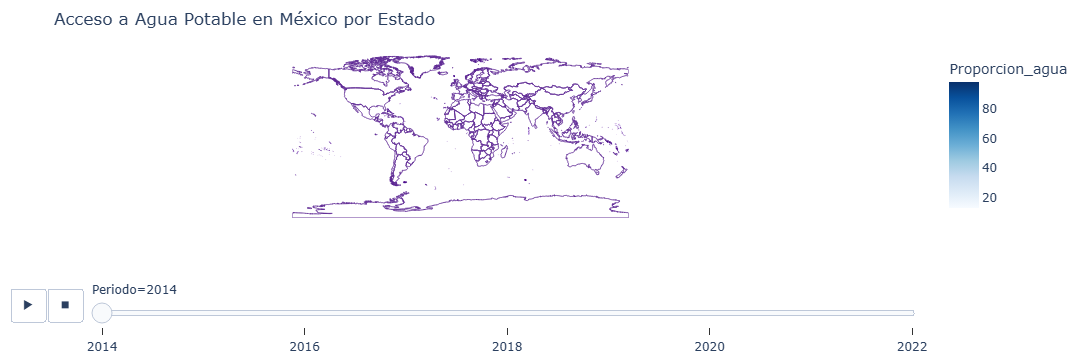

In [3]:
# 1. Cargar y limpiar
ruta='../data/_6_1_1_c_sh_es.csv'
df = pd.read_csv(ruta)
df.columns = ['Periodo', 'cvegeo', 'Entidad', 'Proporcion_agua', 'Extra']

# 2. Limpieza de IDs
# IMPORTANTE: Algunos GeoJSON usan el ID como entero, otros como string con ceros.
df = df[df['cvegeo'].astype(str) != '00']
# Intenta primero sin zfill si el mapa no sale, o verifica el JSON
df['cvegeo'] = df['cvegeo'].astype(str).str.zfill(2) 
df = df.sort_values('Periodo') # Para una animación fluida

repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

fig = px.choropleth(
    data_frame=df,
    geojson=repo_url,
    locations='cvegeo',
    featureidkey='properties.id', # <--- Verifica si es 'id' o 'name' en el JSON
    color='Proporcion_agua',
    animation_frame='Periodo',
    # Usar un rango fijo ayuda a que los colores no salten entre años
    range_color=[df['Proporcion_agua'].min(), df['Proporcion_agua'].max()],
    color_continuous_scale="Blues",
    title="Acceso a Agua Potable en México por Estado"
)

# 4. Ajustar la proyección para que se centre en México
fig.update_geos(
    visible=False, 
    resolution=50,
    showcountries=True, 
    countrycolor="RebeccaPurple",
    fitbounds="locations" # Esto fuerza a la cámara a enfocarse en los datos
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

In [4]:
import requests
repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'
geojson = requests.get(repo_url).json()
print(geojson['features'][0]['properties'])

{'name': 'Zacatecas', 'id': 'MX-ZAC', 'CNTRY': 'Mexico', 'TYPE': 'State'}


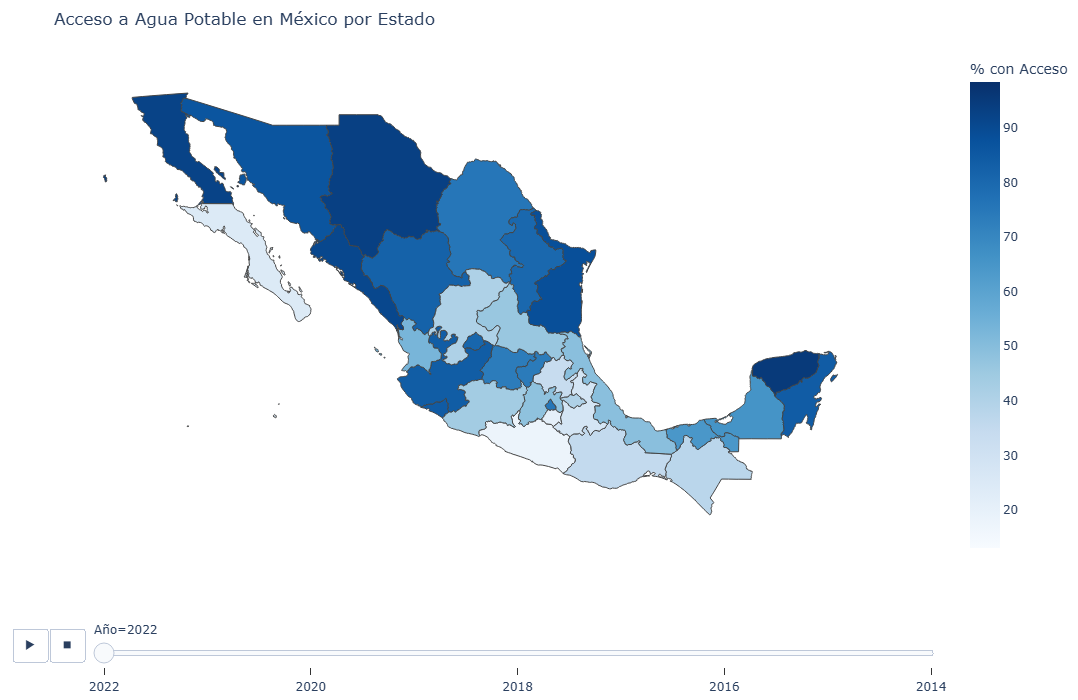

In [5]:
# 1. Diccionario de mapeo (Basado en el estándar ISO que usa tu GeoJSON)
mapeo_mx = {
    '01': 'MX-AGU', '02': 'MX-BCN', '03': 'MX-BCS', '04': 'MX-CAM', '05': 'MX-COA',
    '06': 'MX-COL', '07': 'MX-CHP', '08': 'MX-CHH', '09': 'MX-CMX', '10': 'MX-DUR',
    '11': 'MX-GUA', '12': 'MX-GRO', '13': 'MX-HID', '14': 'MX-JAL', '15': 'MX-MEX',
    '16': 'MX-MIC', '17': 'MX-MOR', '18': 'MX-NAY', '19': 'MX-NLE', '20': 'MX-OAX',
    '21': 'MX-PUE', '22': 'MX-QUE', '23': 'MX-ROO', '24': 'MX-SLP', '25': 'MX-SIN',
    '26': 'MX-SON', '27': 'MX-TAB', '28': 'MX-TAM', '29': 'MX-TLA', '30': 'MX-VER',
    '31': 'MX-YUC', '32': 'MX-ZAC'
}

# 2. Cargar y Limpiar
df = pd.read_csv(ruta)
df.columns = ['Periodo', 'cvegeo', 'Entidad', 'Proporcion_agua', 'Extra']

# 3. Transformación CRÍTICA
df = df[df['cvegeo'].astype(str) != '00']
# Convertimos el número (01) al código del mapa (MX-AGU)
df['cvegeo_iso'] = df['cvegeo'].astype(str).str.zfill(2).map(mapeo_mx)

repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

# 4. Crear el mapa
fig = px.choropleth(
    data_frame=df,
    geojson=repo_url,
    locations='cvegeo_iso',        # Usamos la nueva columna con "MX-..."
    featureidkey='properties.id',   # Esto ahora sí coincidirá con 'MX-ZAC', etc.
    color='Proporcion_agua',
    animation_frame='Periodo',
    range_color=[df['Proporcion_agua'].min(), df['Proporcion_agua'].max()],
    color_continuous_scale="Blues",
    title="Acceso a Agua Potable en México por Estado",
    labels={'Proporcion_agua': '% con Acceso', 'Periodo': 'Año'}
)
# 1. Ajustar el tamaño del lienzo (Height y Width)
# 2. Eliminar márgenes innecesarios
fig.update_layout(
    height=700,         # Aumenta el alto en píxeles
    width=1000,        # Aumenta el ancho en píxeles
    margin={"r":0, "t":50, "l":0, "b":0} # t=50 deja espacio solo para el título
)

# 3. Forzar a que el mapa use todo el espacio disponible
fig.update_geos(
    fitbounds="locations", 
    visible=False,
    projection_scale=1.2 # Opcional: Esto le da un "zoom" extra manual si lo necesitas
)

fig.show()

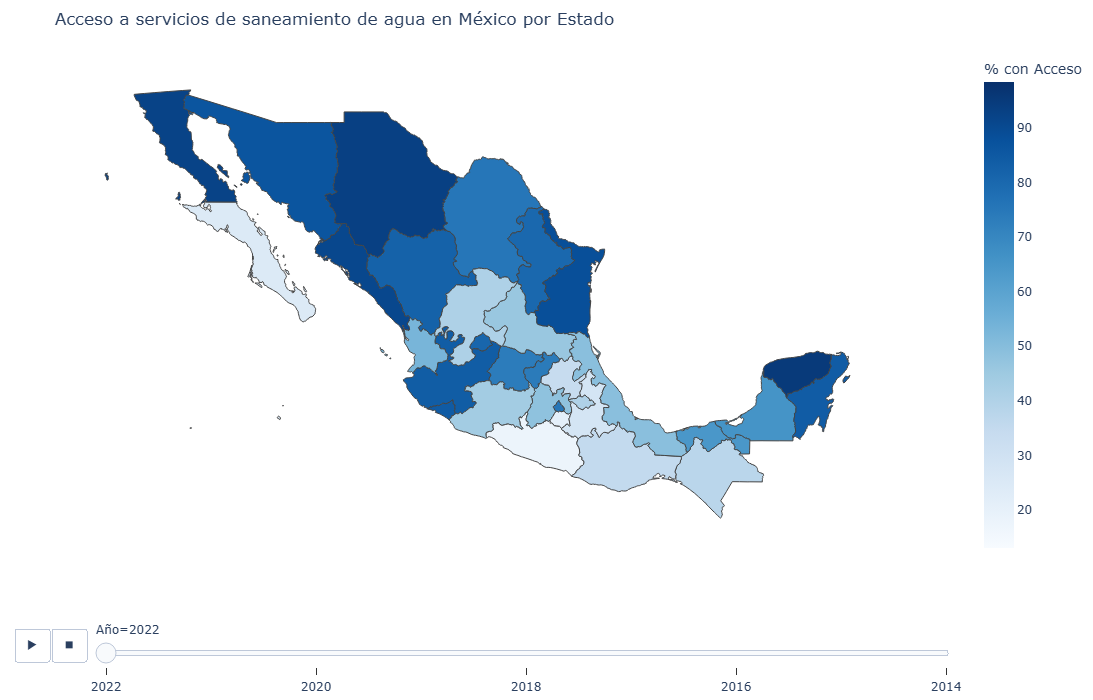

In [6]:
# 1. Diccionario de mapeo (Basado en el estándar ISO que usa tu GeoJSON)
mapeo_mx = {
    '01': 'MX-AGU', '02': 'MX-BCN', '03': 'MX-BCS', '04': 'MX-CAM', '05': 'MX-COA',
    '06': 'MX-COL', '07': 'MX-CHP', '08': 'MX-CHH', '09': 'MX-CMX', '10': 'MX-DUR',
    '11': 'MX-GUA', '12': 'MX-GRO', '13': 'MX-HID', '14': 'MX-JAL', '15': 'MX-MEX',
    '16': 'MX-MIC', '17': 'MX-MOR', '18': 'MX-NAY', '19': 'MX-NLE', '20': 'MX-OAX',
    '21': 'MX-PUE', '22': 'MX-QUE', '23': 'MX-ROO', '24': 'MX-SLP', '25': 'MX-SIN',
    '26': 'MX-SON', '27': 'MX-TAB', '28': 'MX-TAM', '29': 'MX-TLA', '30': 'MX-VER',
    '31': 'MX-YUC', '32': 'MX-ZAC'
}

# 2. Cargar y Limpiar
df = pd.read_csv(ruta)
df.columns = ['Periodo', 'cvegeo', 'Entidad', 'Proporcion_agua', 'Extra']

# 3. Transformación CRÍTICA
df = df[df['cvegeo'].astype(str) != '00']
# Convertimos el número (01) al código del mapa (MX-AGU)
df['cvegeo_iso'] = df['cvegeo'].astype(str).str.zfill(2).map(mapeo_mx)

repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

# 4. Crear el mapa
fig = px.choropleth(
    data_frame=df,
    geojson=repo_url,
    locations='cvegeo_iso',        # Usamos la nueva columna con "MX-..."
    featureidkey='properties.id',   # Esto ahora sí coincidirá con 'MX-ZAC', etc.
    color='Proporcion_agua',
    animation_frame='Periodo',
    range_color=[df['Proporcion_agua'].min(), df['Proporcion_agua'].max()],
    color_continuous_scale="Blues",
    title="Acceso a servicios de saneamiento de agua en México por Estado",
    labels={'Proporcion_agua': '% con Acceso', 'Periodo': 'Año'}
)
# 1. Ajustar el tamaño del lienzo (Height y Width)
# 2. Eliminar márgenes innecesarios
fig.update_layout(
    height=700,         # Aumenta el alto en píxeles
    width=1000,        # Aumenta el ancho en píxeles
    margin={"r":0, "t":50, "l":0, "b":0} # t=50 deja espacio solo para el título
)

# 3. Forzar a que el mapa use todo el espacio disponible
fig.update_geos(
    fitbounds="locations", 
    visible=False,
    projection_scale=1.2 # Opcional: Esto le da un "zoom" extra manual si lo necesitas
)

fig.show()